In [4]:
import requests
import json
import os
import pandas as pd

def load_data_from_api():
    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming"

    # 1. API 호출
    response = requests.get(url)

    # 2. 결과 확인 (200 OK인지 확인)
    if response.status_code == 200:
        data = response.json()

        # 3. 폴더 생성 및 JSON 저장
        os.makedirs('data_folder', exist_ok=True)
        with open('data_folder/launches.json', 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)

        # 4. DataFrame으로 변환하여 구조 확인
        # 'results' 키 안에 실제 발사 목록이 들어있을 겁니다.
        df = pd.DataFrame(data['results'])
        print(df.head())
        return df
    else:
        print("데이터를 가져오는 데 실패했습니다.")
        return None

In [5]:
def get_pictures():
    # 1. JSON 파일 읽기
    with open('data_folder/launches.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    os.makedirs('images', exist_ok=True)

    for item in data['results']:
        image_url = item.get('image') # image 키가 없을 수도 있으니 .get() 사용
        name = item.get('name').replace(" ", "_") # 파일명으로 쓰기 위해 공백 제거

        if image_url:
            try:
                # 2. 이미지 데이터 요청 (stream=True는 대용량 파일에 효율적)
                img_res = requests.get(image_url, timeout=10)
                img_res.raise_for_status() # 404, 500 에러 시 예외 발생

                # 3. 이미지 저장 (바이너리 모드 'wb' 필수!)
                with open(f'images/{name}.jpg', 'wb') as f:
                    f.write(img_res.content)
                print(f"다운로드 완료: {name}")

            except requests.exceptions.RequestException as e:
                print(f"다운로드 실패 ({name}): {e}")

                                     id  \
0  2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd   
1  1d24bfe7-d524-41f0-85de-09e967618710   
2  6f2868b8-1000-48e5-893b-700c1371b4fb   
3  d44f47c7-5e3e-40fb-9d10-b6e851acf81a   
4  f8766455-2b03-4629-a36e-b931c8b4a6c5   

                                                 url launch_library_id  \
0  https://ll.thespacedevs.com/2.0.0/launch/2e3e3...              None   
1  https://ll.thespacedevs.com/2.0.0/launch/1d24b...              None   
2  https://ll.thespacedevs.com/2.0.0/launch/6f286...              None   
3  https://ll.thespacedevs.com/2.0.0/launch/d44f4...              None   
4  https://ll.thespacedevs.com/2.0.0/launch/f8766...              None   

                                    slug  \
0      long-march-8a-satnet-leo-group-20   
1          long-march-2d-shiyan-30-03-04   
2  falcon-9-block-5-starlink-group-10-48   
3  falcon-9-block-5-starlink-group-17-31   
4          long-march-6a-unknown-payload   

                               

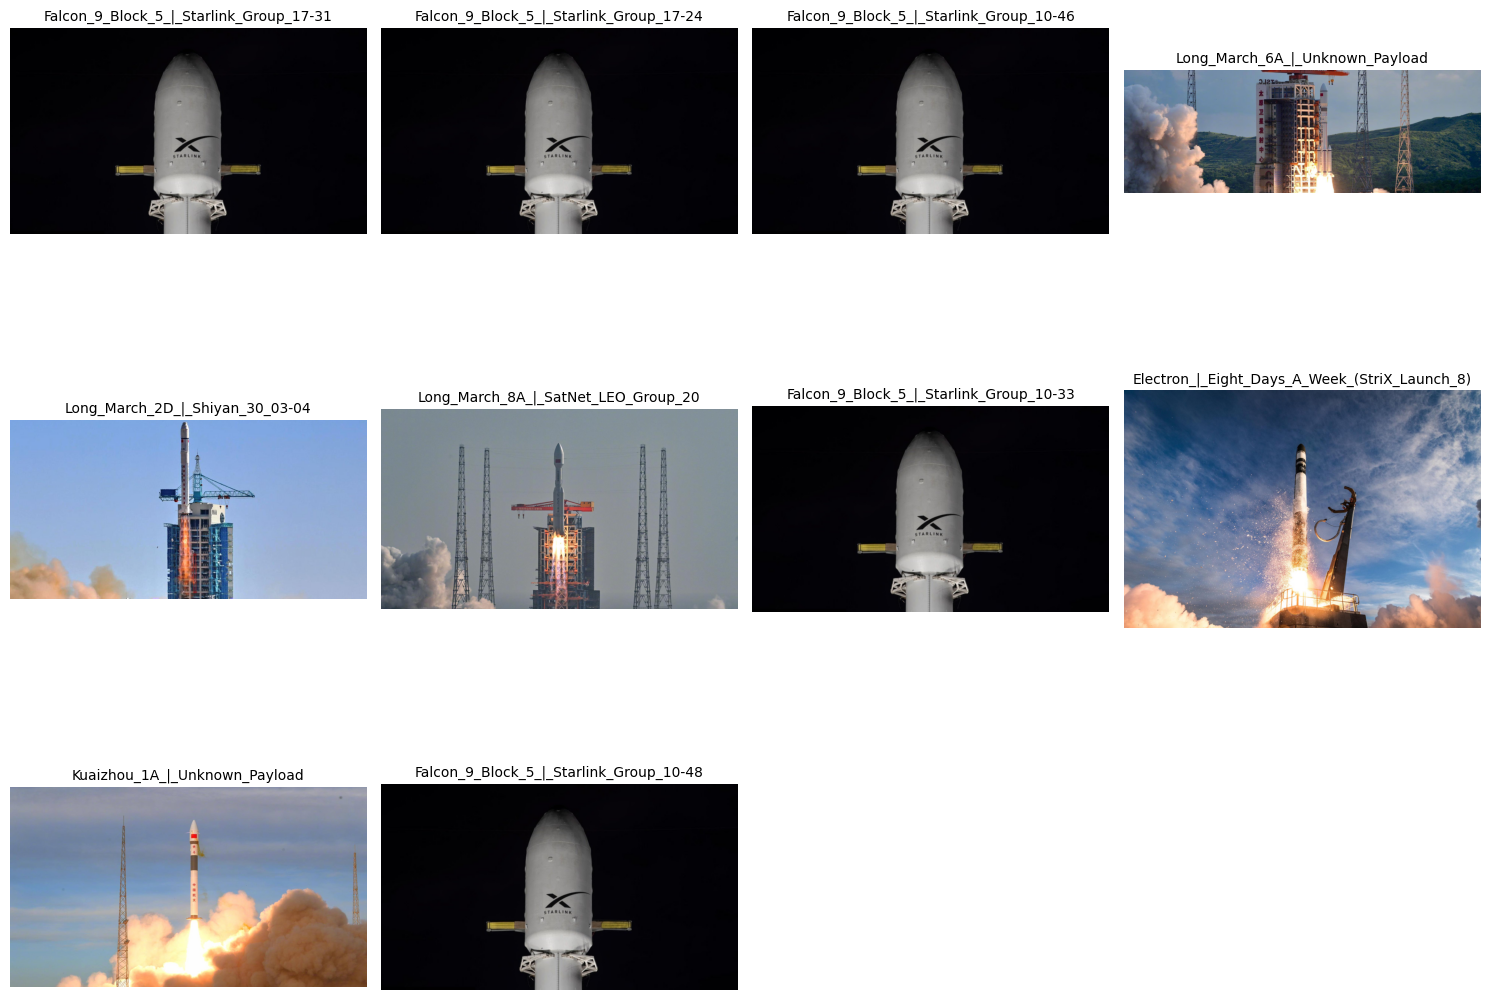

In [12]:
load_data_from_api()
get_pictures()
visualize_launches()